# Classification Model Comparison

Put `train.csv` and `test.csv` in the same directory as this notebook.

- Set `TARGET_COLUMN` to your target column.
- No feature preprocessing is performed.
- Stratified K-fold CV and hyperparameter tuning use **train.csv only**.
- `test.csv` is used only for final evaluation.
- The final cell reports **Accuracy, Balanced Accuracy, Precision, Recall, F1 and ROC-AUC when available**.
- A **confusion matrix** is displayed for every model.
- For binary classification, ROC-AUC is reported normally.
- For multiclass classification, weighted one-vs-one ROC-AUC is used when the model provides probabilities or decision scores.


In [2]:
# Common imports and data loading
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

TARGET_COLUMN = "target"   # <-- CHANGE THIS

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

X = train.drop(columns=[TARGET_COLUMN])
y = train[TARGET_COLUMN]

X_test = test.drop(columns=[TARGET_COLUMN])
y_test = test[TARGET_COLUMN]

# StratifiedKFold keeps class proportions similar across folds.
CV = StratifiedKFold(n_splits=2, shuffle=True, random_state=0)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Number of classes:", y.nunique())
print("Classes:", sorted(y.unique()))


Train shape: (1600, 21)
Test shape : (400, 21)
Number of classes: 2
Classes: [np.int64(0), np.int64(1)]


## 1. Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

classifier = LogisticRegression(
    max_iter=1000,
    random_state=0
)

# C: inverse regularization strength; smaller values apply stronger regularization.
# penalty: type of regularization used to control model complexity.
# solver: optimization algorithm used to fit the model.
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.01}
Best 2-Fold CV Accuracy: 0.8531249999999999


## 2. K-Nearest Neighbour (KNN)

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = KNeighborsClassifier()

# n_neighbors: number of nearby samples used to vote for the class.
# weights: determines whether closer neighbours have more influence.
# p: distance metric power; 1 = Manhattan distance, 2 = Euclidean distance.
param_grid = {
    "n_neighbors": [3, 5, 7, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'weights': 'uniform', 'p': 2, 'n_neighbors': 3}
Best 2-Fold CV Accuracy: 0.9143749999999999


## 3. Support Vector Machine + Kernel SVM

In [5]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

classifier = SVC(
    probability=True,
    random_state=0
)

# kernel: "linear" gives a linear SVM; "rbf" and "poly" are kernel SVMs
#       that can model non-linear decision boundaries.
# C: penalty for misclassification; larger values fit training data more strictly.
# gamma: controls how far the influence of each training point reaches for
#        RBF/poly kernels.
# degree: polynomial kernel degree; used only when kernel="poly".
param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"]
    },
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "degree": [2, 3]
    }
]

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}
Best 2-Fold CV Accuracy: 0.9312499999999999


## 4. Naive Bayes

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV

classifier = GaussianNB()

# var_smoothing: adds a small value to feature variances for numerical stability.
param_grid = {
    "var_smoothing": [1e-11, 1e-9, 1e-7, 1e-5]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'var_smoothing': 1e-09}
Best 2-Fold CV Accuracy: 0.816875


## 5. Decision Tree

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = DecisionTreeClassifier(
    random_state=0
)

# max_depth: maximum tree depth; controls model complexity.
# min_samples_split: minimum samples needed to split an internal node.
# min_samples_leaf: minimum samples allowed in a leaf.
# criterion: function used to measure the quality of a split.
param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10, 'criterion': 'entropy'}
Best 2-Fold CV Accuracy: 0.82875


## 6. Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = RandomForestClassifier(
    random_state=0,
    n_jobs=1
)

# n_estimators: number of decision trees in the forest.
# max_depth: maximum depth of each tree; controls complexity.
# min_samples_split: minimum samples needed to split a node.
# max_features: number of features considered when looking for each split.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 10}
Best 2-Fold CV Accuracy: 0.911875


## 7. XGBoost Classifier

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    random_state=0,
    eval_metric="logloss",
    n_jobs=1
)

# n_estimators: number of boosting trees.
# learning_rate: size of each boosting step.
# max_depth: maximum depth of each tree; controls complexity.
# subsample: fraction of training rows used by each tree; can reduce overfitting.
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Best 2-Fold CV Accuracy: 0.92125


## 8. LightGBM Classifier

In [10]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=0,
    verbosity=-1,
    n_jobs=1
)

# n_estimators: number of boosting iterations.
# learning_rate: contribution of each boosting tree.
# num_leaves: controls tree complexity; larger values can model more complex patterns.
# max_depth: limits tree depth; -1 means no explicit limit.
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 10]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'num_leaves': 63, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.1}
Best 2-Fold CV Accuracy: 0.921875


## 9. CatBoost Classifier

In [11]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    verbose=False,
    random_seed=0,
    thread_count=-1
)

# iterations: number of boosting rounds.
# learning_rate: contribution of each boosting round.
# depth: depth of the trees; higher values increase model complexity.
param_grid = {
    "iterations": [100, 200],
    "learning_rate": [0.05, 0.1],
    "depth": [4, 6, 8]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'learning_rate': 0.1, 'iterations': 200, 'depth': 8}
Best 2-Fold CV Accuracy: 0.921875


## Final Test-Set Evaluation


Logistic Regression
Best parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}
CV Accuracy: 0.845
Test Accuracy: 0.8575
Balanced Accuracy: 0.8443089746576584
Weighted Precision: 0.8578690270736706
Weighted Recall: 0.8575
Weighted F1: 0.8560470013643644
ROC-AUC: 0.9334213455515001

Confusion Matrix:
[[217  20]
 [ 37 126]]


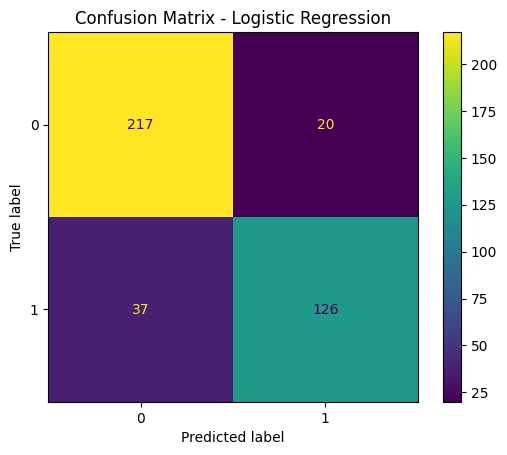


KNN
Best parameters: {'weights': 'distance', 'p': 2, 'n_neighbors': 7}
CV Accuracy: 0.913125
Test Accuracy: 0.92
Balanced Accuracy: 0.9095027309673578
Weighted Precision: 0.9216175956548628
Weighted Recall: 0.92
Weighted F1: 0.9192416063199473
ROC-AUC: 0.9769356216510057

Confusion Matrix:
[[229   8]
 [ 24 139]]


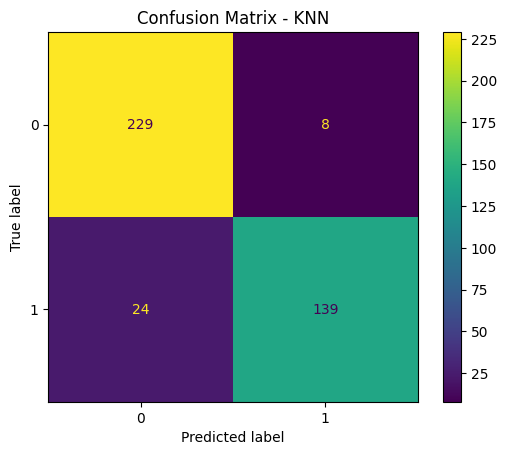


SVM + Kernel SVM
Best parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}
CV Accuracy: 0.9312499999999999
Test Accuracy: 0.94
Balanced Accuracy: 0.9359581683104243
Weighted Precision: 0.9399519820454606
Weighted Recall: 0.94
Weighted F1: 0.9398783752176512
ROC-AUC: 0.9856074137350832

Confusion Matrix:
[[227  10]
 [ 14 149]]


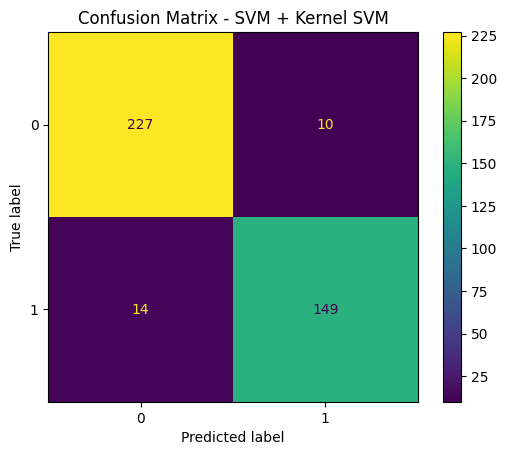


Naive Bayes
Best parameters: {'var_smoothing': 1e-09}
CV Accuracy: 0.816875
Test Accuracy: 0.8325
Balanced Accuracy: 0.8241697082653827
Weighted Precision: 0.8319069724866618
Weighted Recall: 0.8325
Weighted F1: 0.8320696999850415
ROC-AUC: 0.9082343195878957

Confusion Matrix:
[[206  31]
 [ 36 127]]


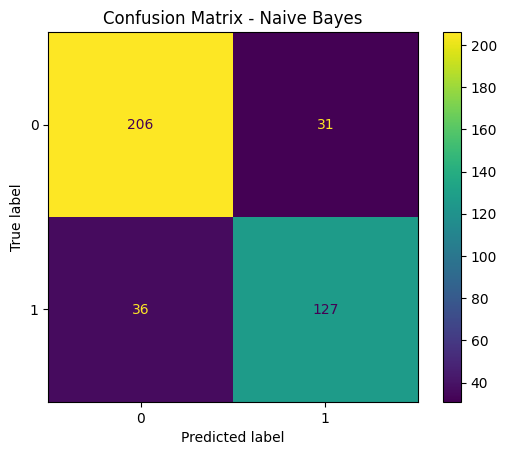


Decision Tree
Best parameters: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy'}
CV Accuracy: 0.823125
Test Accuracy: 0.85
Balanced Accuracy: 0.8389376407548342
Weighted Precision: 0.8495691374770605
Weighted Recall: 0.85
Weighted F1: 0.8489856098136354
ROC-AUC: 0.8882115399549585

Confusion Matrix:
[[213  24]
 [ 36 127]]


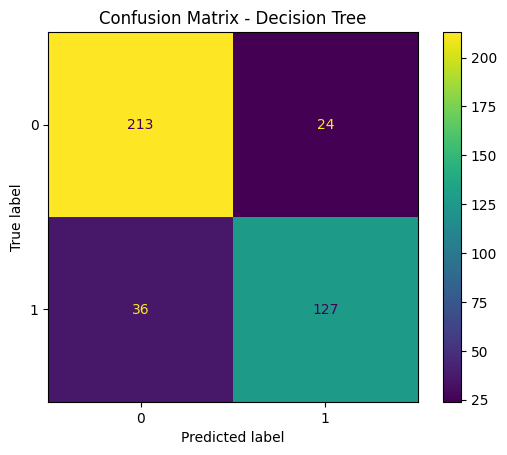


Random Forest
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 20}
CV Accuracy: 0.910625
Test Accuracy: 0.925
Balanced Accuracy: 0.9156377002925111
Weighted Precision: 0.9261885344527928
Weighted Recall: 0.925
Weighted F1: 0.9243931273644388
ROC-AUC: 0.9773886257150992

Confusion Matrix:
[[229   8]
 [ 22 141]]


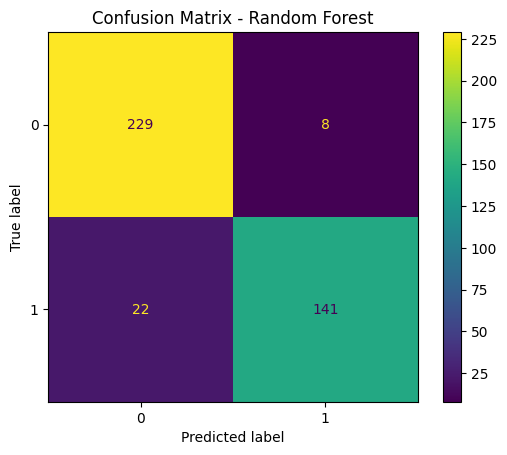


XGBoost Classifier
Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
CV Accuracy: 0.923125
Test Accuracy: 0.9375
Balanced Accuracy: 0.9309751236053947
Weighted Precision: 0.9378860468799494
Weighted Recall: 0.9375
Weighted F1: 0.9371950741618826
ROC-AUC: 0.9832259066552769

Confusion Matrix:
[[229   8]
 [ 17 146]]


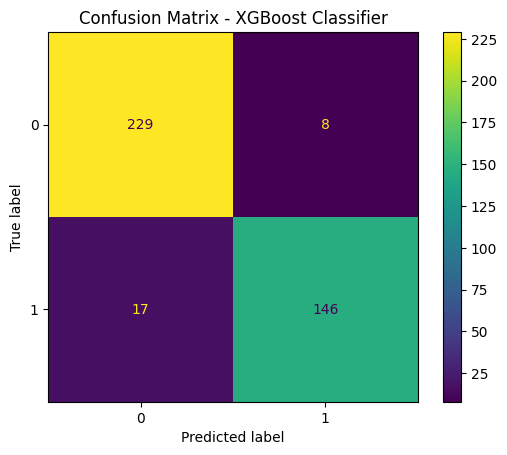


LightGBM Classifier
Best parameters: {'num_leaves': 63, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.1}
CV Accuracy: 0.921875
Test Accuracy: 0.935
Balanced Accuracy: 0.9279076389428179
Weighted Precision: 0.9355146728056946
Weighted Recall: 0.935
Weighted F1: 0.9346430065906475
ROC-AUC: 0.9780228314048303

Confusion Matrix:
[[229   8]
 [ 18 145]]


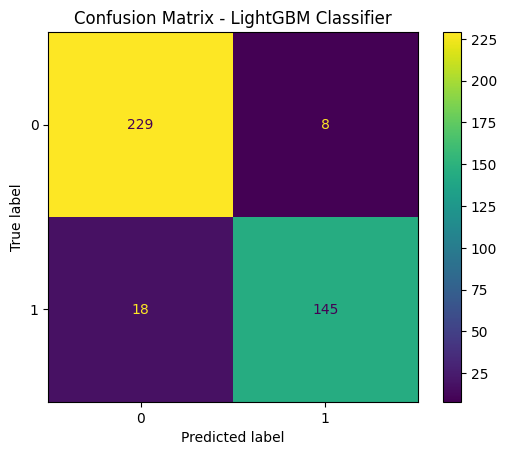


CatBoost Classifier
Best parameters: {'learning_rate': 0.1, 'iterations': 200, 'depth': 8}
CV Accuracy: 0.9281250000000001
Test Accuracy: 0.9425
Balanced Accuracy: 0.9380678729517745
Weighted Precision: 0.9425111151794121
Weighted Recall: 0.9425
Weighted F1: 0.942352285069492
ROC-AUC: 0.9843907742486604

Confusion Matrix:
[[228   9]
 [ 14 149]]


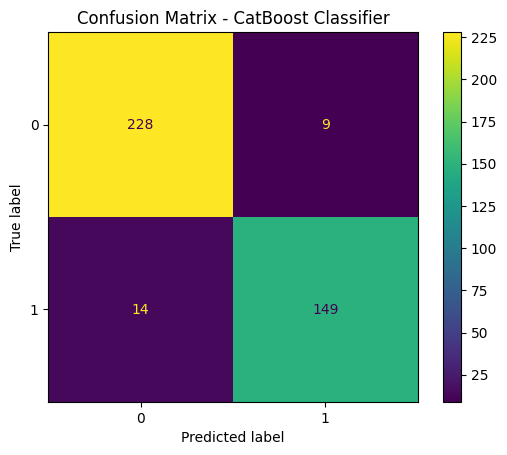

,Model,Accuracy,Balanced Accuracy,Weighted Precision,Weighted Recall,Weighted F1,ROC-AUC,Best Hyperparameters
0,CatBoost Classifier,0.9425,0.938068,0.942511,0.9425,0.942352,0.984391,"{'learning_rate': 0.1, 'iterations': 200, 'dep..."
1,SVM + Kernel SVM,0.9400,0.935958,0.939952,0.9400,0.939878,0.985607,"{'kernel': 'rbf', 'gamma': 'scale', 'C': 1}"
2,XGBoost Classifier,0.9375,0.930975,0.937886,0.9375,0.937195,0.983226,"{'subsample': 0.8, 'n_estimators': 200, 'max_d..."
3,LightGBM Classifier,0.9350,0.927908,0.935515,0.9350,0.934643,0.978023,"{'num_leaves': 63, 'n_estimators': 100, 'max_d..."
4,Random Forest,0.9250,0.915638,0.926189,0.9250,0.924393,0.977389,"{'n_estimators': 200, 'min_samples_split': 2, ..."
5,KNN,0.9200,0.909503,0.921618,0.9200,0.919242,0.976936,"{'weights': 'distance', 'p': 2, 'n_neighbors': 7}"
6,Logistic Regression,0.8575,0.844309,0.857869,0.8575,0.856047,0.933421,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}"
7,Decision Tree,0.8500,0.838938,0.849569,0.8500,0.848986,0.888212,"{'min_samples_split': 5, 'min_samples_leaf': 4..."
8,Naive Bayes,0.8325,0.824170,0.831907,0.8325,0.832070,0.908234,{'var_smoothing': 1e-09}


Best model by test Accuracy: CatBoost Classifier
Best test Accuracy: 0.9425
Selected Hyperparameters:
{'learning_rate': 0.1, 'iterations': 200, 'depth': 8}


In [12]:
# IMPORTANT:
# Every model is tuned using train.csv only.
# The best configuration is then refit on all of train.csv.
# test.csv remains completely untouched until this cell.

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "Logistic Regression": RandomizedSearchCV(
        LogisticRegression(max_iter=1000, random_state=0),
        {
            "C": [0.01, 0.1, 1, 10, 100],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        },
        cv=CV, scoring="accuracy", n_iter=3, n_jobs=1
    ),

    "KNN": RandomizedSearchCV(
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7, 11],
            "weights": ["uniform", "distance"],
            "p": [1, 2]
        },
        cv=CV, scoring="accuracy", n_iter=3, n_jobs=1
    ),

    "SVM + Kernel SVM": RandomizedSearchCV(
        SVC(probability=True, random_state=0),
        [
            {"kernel": ["linear"], "C": [0.1, 1, 10, 100]},
            {
                "kernel": ["rbf"],
                "C": [0.1, 1, 10, 100],
                "gamma": ["scale", "auto"]
            },
            {
                "kernel": ["poly"],
                "C": [0.1, 1, 10],
                "gamma": ["scale", "auto"],
                "degree": [2, 3]
            }
        ],
        cv=CV, scoring="accuracy", n_iter=3, n_jobs=1
    ),

    "Naive Bayes": RandomizedSearchCV(
        GaussianNB(),
        {"var_smoothing": [1e-11, 1e-9, 1e-7, 1e-5]},
        cv=CV, scoring="accuracy", n_iter=3, n_jobs=1
    ),

    "Decision Tree": RandomizedSearchCV(
        DecisionTreeClassifier(random_state=0),
        {
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "criterion": ["gini", "entropy"]
        },
        cv=CV, scoring="accuracy", n_iter=3, n_jobs=1
    ),

    "Random Forest": RandomizedSearchCV(
        RandomForestClassifier(random_state=0, n_jobs=1),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5],
            "max_features": ["sqrt", "log2"]
        },
        cv=CV, scoring="accuracy", n_iter=3, n_jobs=1
    ),

    "XGBoost Classifier": RandomizedSearchCV(
        XGBClassifier(
            random_state=0,
            eval_metric="logloss",
            n_jobs=1
        ),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5],
            "subsample": [0.8, 1.0]
        },
        cv=CV, scoring="accuracy", n_iter=3, n_jobs=1
    ),

    "LightGBM Classifier": RandomizedSearchCV(
        LGBMClassifier(
            random_state=0,
            verbosity=-1,
            n_jobs=1
        ),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "num_leaves": [15, 31, 63],
            "max_depth": [-1, 10]
        },
        cv=CV, scoring="accuracy", n_iter=3, n_jobs=1
    ),

    "CatBoost Classifier": RandomizedSearchCV(
        CatBoostClassifier(
            verbose=False,
            random_seed=0,
            thread_count=-1
        ),
        {
            "iterations": [100, 200],
            "learning_rate": [0.05, 0.1],
            "depth": [4, 6, 8]
        },
        cv=CV, scoring="accuracy", n_iter=3, n_jobs=1
    )
}


def get_roc_auc(model, X_eval, y_eval):
    """Return ROC-AUC when the fitted model exposes usable scores."""
    try:
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_eval)
            if scores.shape[1] == 2:
                return roc_auc_score(y_eval, scores[:, 1])
            return roc_auc_score(
                y_eval, scores,
                multi_class="ovr",
                average="weighted"
            )

        if hasattr(model, "decision_function"):
            scores = model.decision_function(X_eval)
            if np.ndim(scores) == 1:
                return roc_auc_score(y_eval, scores)
            return roc_auc_score(
                y_eval, scores,
                multi_class="ovr",
                average="weighted"
            )
    except Exception:
        return np.nan

    return np.nan


results = []

for name, model in models.items():

    print("\n" + "=" * 70)
    print(name)

    # Tune using train.csv only, then refit the best configuration on all training data.
    model.fit(X, y)

    predictions = model.predict(X_test)
    best_model = model.best_estimator_

    accuracy = accuracy_score(y_test, predictions)
    balanced_accuracy = balanced_accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test, predictions,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test, predictions,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test, predictions,
        average="weighted",
        zero_division=0
    )
    roc_auc = get_roc_auc(best_model, X_test, y_test)

    cm = confusion_matrix(y_test, predictions)

    print("Best parameters:", model.best_params_)
    print("CV Accuracy:", model.best_score_)
    print("Test Accuracy:", accuracy)
    print("Balanced Accuracy:", balanced_accuracy)
    print("Weighted Precision:", precision)
    print("Weighted Recall:", recall)
    print("Weighted F1:", f1)
    print("ROC-AUC:", roc_auc)
    print("\nConfusion Matrix:")
    print(cm)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(y_test)
    ).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    results.append([
        name,
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        model.best_params_
    ])


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "ROC-AUC",
        "Best Hyperparameters"
    ]
)

results_df = results_df.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_df)

best_row = results_df.iloc[0]

print("Best model by test Accuracy:", best_row["Model"])
print("Best test Accuracy:", best_row["Accuracy"])
print("Selected Hyperparameters:")
print(best_row["Best Hyperparameters"])
